In [1]:
import pandas as pd
import json

users = pd.read_csv("../raw/users.csv")
sessions = pd.read_csv("../raw/sessions.csv")
events = pd.read_csv("../raw/events.csv")
orders = pd.read_csv("../raw/orders.csv")
order_items = pd.read_csv("../raw/order_items.csv")
campaigns = pd.read_csv("../raw/campaigns.csv")

with open("../raw/products.json") as f:
    products = pd.json_normalize(json.load(f))

print(users.shape)
print(sessions.shape)
print(events.shape)
print(orders.shape)
print(order_items.shape)
print(products.shape)
print(campaigns.shape)


(2200, 5)
(9036, 8)
(18945, 3)
(707, 9)
(1797, 4)
(220, 6)
(40, 3)


In [2]:
users.columns

Index(['user_id', 'signup_date', 'city_tier', 'segment', 'preferred_device'], dtype='object')

In [3]:
sessions.columns

Index(['session_id', 'user_id', 'session_start_ts', 'device', 'channel',
       'campaign_id', 'variant', 'is_new_user'],
      dtype='object')

In [4]:
events.columns

Index(['session_id', 'event_ts', 'event_type'], dtype='object')

In [5]:
orders.columns

Index(['order_id', 'session_id', 'user_id', 'order_ts', 'gross_amount',
       'discount_amount', 'shipping_amount', 'net_amount', 'payment_method'],
      dtype='object')

In [6]:
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')

In [7]:
products.columns

Index(['product_id', 'category', 'brand', 'price', 'cost', 'rating'], dtype='object')

In [8]:
campaigns.columns

Index(['campaign_id', 'channel', 'campaign_name'], dtype='object')

In [9]:
events["event_type"].unique()

array(['landing_view', 'product_view', 'add_to_cart', 'begin_checkout',
       'payment_attempt', 'purchase'], dtype=object)

In [10]:
funnel_flags = events.pivot_table(
    index="session_id",
    columns="event_type",
    aggfunc="size",
    fill_value=0
)

# Convert counts to binary flags
funnel_flags = (funnel_flags > 0).astype(int)

funnel_flags.head()

event_type,add_to_cart,begin_checkout,landing_view,payment_attempt,product_view,purchase
session_id,,,,,,
S0000001,0,0,1,0,0,0
S0000002,0,0,1,0,0,0
S0000003,0,0,1,0,1,0
S0000004,0,0,1,0,0,0
S0000005,0,0,1,0,1,0


In [11]:
funnel_flags = funnel_flags[
    ["product_view", "add_to_cart", "begin_checkout", "payment_attempt", "purchase"]
]

funnel_flags.head()

event_type,product_view,add_to_cart,begin_checkout,payment_attempt,purchase
session_id,,,,,
S0000001,0,0,0,0,0
S0000002,0,0,0,0,0
S0000003,1,0,0,0,0
S0000004,0,0,0,0,0
S0000005,1,0,0,0,0


In [12]:
fact_sessions = sessions.merge(
    funnel_flags,
    on="session_id",
    how="left"
)

fact_sessions.head()

,session_id,user_id,session_start_ts,device,channel,campaign_id,variant,is_new_user,product_view,add_to_cart,begin_checkout,payment_attempt,purchase
0,S0000001,U001627,2025-10-26T15:56:31,web,organic,C025,A,1,0,0,0,0,0
1,S0000002,U001038,2025-12-09T21:56:53,mobile,paid_social,C037,NaN,0,0,0,0,0,0
2,S0000003,NaN,2025-11-24T21:24:21,web,organic,C034,NaN,0,1,0,0,0,0
3,S0000004,U001072,2025-12-02T06:51:38,mobile,organic,C013,NaN,0,0,0,0,0,0
4,S0000005,U001301,2025-11-28T16:03:05,mobile,paid_social,C004,NaN,1,1,0,0,0,0


In [13]:
funnel_cols = ["product_view","add_to_cart","begin_checkout","payment_attempt","purchase"]

fact_sessions[funnel_cols] = fact_sessions[funnel_cols].fillna(0).astype(int)

In [14]:
fact_sessions.shape

(9036, 13)

In [15]:
orders.columns

Index(['order_id', 'session_id', 'user_id', 'order_ts', 'gross_amount',
       'discount_amount', 'shipping_amount', 'net_amount', 'payment_method'],
      dtype='object')

In [16]:
session_revenue = orders.groupby("session_id").agg({
    "gross_amount": "sum",
    "discount_amount": "sum",
    "shipping_amount": "sum",
    "net_amount": "sum"
}).reset_index()

session_revenue.head()

,session_id,gross_amount,discount_amount,shipping_amount,net_amount
0,S0000015,4145.06,49.97,0.00,4095.09
1,S0000060,4302.50,151.09,0.00,4151.41
2,S0000073,7199.78,596.95,0.00,6602.83
3,S0000081,1262.26,75.40,117.27,1304.13
4,S0000084,13486.98,1087.51,0.00,12399.47


In [17]:
fact_sessions = fact_sessions.merge(
    session_revenue,
    on="session_id",
    how="left"
)

fact_sessions.head()

,session_id,user_id,session_start_ts,device,channel,campaign_id,variant,is_new_user,product_view,add_to_cart,begin_checkout,payment_attempt,purchase,gross_amount,discount_amount,shipping_amount,net_amount
0,S0000001,U001627,2025-10-26T15:56:31,web,organic,C025,A,1,0,0,0,0,0,NaN,NaN,NaN,NaN
1,S0000002,U001038,2025-12-09T21:56:53,mobile,paid_social,C037,NaN,0,0,0,0,0,0,NaN,NaN,NaN,NaN
2,S0000003,NaN,2025-11-24T21:24:21,web,organic,C034,NaN,0,1,0,0,0,0,NaN,NaN,NaN,NaN
3,S0000004,U001072,2025-12-02T06:51:38,mobile,organic,C013,NaN,0,0,0,0,0,0,NaN,NaN,NaN,NaN
4,S0000005,U001301,2025-11-28T16:03:05,mobile,paid_social,C004,NaN,1,1,0,0,0,0,NaN,NaN,NaN,NaN


In [18]:
revenue_cols = ["gross_amount","discount_amount","shipping_amount","net_amount"]

fact_sessions[revenue_cols] = fact_sessions[revenue_cols].fillna(0)

In [19]:
fact_sessions[["purchase","net_amount"]].head(10)

,purchase,net_amount
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
5,0,0.0
6,0,0.0
7,0,0.0
8,0,0.0
9,0,0.0


In [20]:
events.head()

,session_id,event_ts,event_type
0,S0000001,2025-10-26T15:57:00,landing_view
1,S0000002,2025-12-09T21:57:20,landing_view
2,S0000003,2025-11-24T21:24:50,landing_view
3,S0000003,2025-11-24T21:25:13,product_view
4,S0000004,2025-12-02T06:53:06,landing_view


In [21]:
events["event_ts"] = pd.to_datetime(events["event_ts"])

In [22]:
event_times = events.pivot_table(
    index="session_id",
    columns="event_type",
    values="event_ts",
    aggfunc="min"
)

event_times.head()

event_type,add_to_cart,begin_checkout,landing_view,payment_attempt,product_view,purchase
session_id,,,,,,
S0000001,NaT,NaT,2025-10-26 15:57:00,NaT,NaT,NaT
S0000002,NaT,NaT,2025-12-09 21:57:20,NaT,NaT,NaT
S0000003,NaT,NaT,2025-11-24 21:24:50,NaT,2025-11-24 21:25:13,NaT
S0000004,NaT,NaT,2025-12-02 06:53:06,NaT,NaT,NaT
S0000005,NaT,NaT,2025-11-28 16:04:04,NaT,2025-11-28 16:05:44,NaT


In [23]:
event_times["time_to_cart_sec"] = (
    event_times["add_to_cart"] - event_times["product_view"]
).dt.total_seconds()

event_times["time_to_checkout_sec"] = (
    event_times["begin_checkout"] - event_times["add_to_cart"]
).dt.total_seconds()

event_times["time_to_purchase_sec"] = (
    event_times["purchase"] - event_times["begin_checkout"]
).dt.total_seconds()

In [24]:
session_duration = events.groupby("session_id")["event_ts"].agg(["min","max"])
session_duration["session_duration_sec"] = (
    session_duration["max"] - session_duration["min"]
).dt.total_seconds()

session_duration = session_duration[["session_duration_sec"]]

In [25]:
fact_sessions = fact_sessions.merge(
    event_times[[
        "time_to_cart_sec",
        "time_to_checkout_sec",
        "time_to_purchase_sec"
    ]],
    on="session_id",
    how="left"
)

fact_sessions = fact_sessions.merge(
    session_duration,
    on="session_id",
    how="left"
)

In [26]:
fact_sessions.head()

,session_id,user_id,session_start_ts,device,channel,campaign_id,variant,is_new_user,product_view,add_to_cart,...,payment_attempt,purchase,gross_amount,discount_amount,shipping_amount,net_amount,time_to_cart_sec,time_to_checkout_sec,time_to_purchase_sec,session_duration_sec
0,S0000001,U001627,2025-10-26T15:56:31,web,organic,C025,A,1,0,0,...,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
1,S0000002,U001038,2025-12-09T21:56:53,mobile,paid_social,C037,NaN,0,0,0,...,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
2,S0000003,NaN,2025-11-24T21:24:21,web,organic,C034,NaN,0,1,0,...,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,23.0
3,S0000004,U001072,2025-12-02T06:51:38,mobile,organic,C013,NaN,0,0,0,...,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
4,S0000005,U001301,2025-11-28T16:03:05,mobile,paid_social,C004,NaN,1,1,0,...,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,100.0


In [27]:
funnel = fact_sessions[[
    "product_view",
    "add_to_cart",
    "begin_checkout",
    "payment_attempt",
    "purchase"
]].mean()

funnel

product_view       0.626826
add_to_cart        0.177402
begin_checkout     0.111000
payment_attempt    0.111000
purchase           0.078353
dtype: float64

In [28]:
step_conversion = {
    "view_to_cart": fact_sessions["add_to_cart"].sum() / fact_sessions["product_view"].sum(),
    "cart_to_checkout": fact_sessions["begin_checkout"].sum() / fact_sessions["add_to_cart"].sum(),
    "checkout_to_payment": fact_sessions["payment_attempt"].sum() / fact_sessions["begin_checkout"].sum(),
    "payment_to_purchase": fact_sessions["purchase"].sum() / fact_sessions["payment_attempt"].sum()
}

step_conversion

{'view_to_cart': np.float64(0.2830155367231638),
 'cart_to_checkout': np.float64(0.6257018091079226),
 'checkout_to_payment': np.float64(1.0),
 'payment_to_purchase': np.float64(0.7058823529411765)}

In [29]:
conversion_rate = fact_sessions["purchase"].mean()
conversion_rate

np.float64(0.07835325365205843)

In [30]:
revenue_per_session = fact_sessions["net_amount"].mean()
revenue_per_session

np.float64(606.2821480743692)

In [31]:
fact_sessions["variant"].value_counts()

variant
A    1527
B    1482
Name: count, dtype: int64

In [32]:
fact_sessions.groupby("variant")["purchase"].mean()

variant
A    0.083824
B    0.099865
Name: purchase, dtype: float64

In [33]:
fact_sessions.groupby("variant")["net_amount"].mean()


variant
A    882.467446
B    717.509906
Name: net_amount, dtype: float64

In [34]:
from scipy.stats import ttest_ind

A = fact_sessions[fact_sessions["variant"]=="A"]["purchase"]
B = fact_sessions[fact_sessions["variant"]=="B"]["purchase"]

ttest_ind(A, B)

TtestResult(statistic=np.float64(-1.5241336402582684), pvalue=np.float64(0.1275804885810944), df=np.float64(3007.0))

In [35]:
fact_sessions.groupby("variant")["net_amount"].sum()

variant
A    1347527.79
B    1063349.68
Name: net_amount, dtype: float64

In [36]:
fact_sessions.groupby("channel")["purchase"].mean().sort_values(ascending=False)

channel
PAID_SOCIAL    0.133333
ORGANIC        0.125000
SEARCH         0.120000
search         0.085767
organic        0.077583
email          0.076735
referral       0.074480
paid_social    0.072133
EMAIL          0.071429
REFERRAL       0.000000
Name: purchase, dtype: float64

In [37]:
fact_sessions.groupby("device")["purchase"].mean()

device
mobile    0.061399
web       0.092938
Name: purchase, dtype: float64

In [38]:
fact_sessions[fact_sessions["purchase"]==1].groupby("variant")["net_amount"].mean()

variant
A    10527.560859
B     7184.795135
Name: net_amount, dtype: float64

In [39]:
fact_sessions.groupby("variant")[[
"product_view",
"add_to_cart",
"begin_checkout",
"payment_attempt",
"purchase"
]].mean()

,product_view,add_to_cart,begin_checkout,payment_attempt,purchase
variant,,,,,
A,0.608382,0.174853,0.115914,0.115914,0.083824
B,0.640351,0.207827,0.143050,0.143050,0.099865


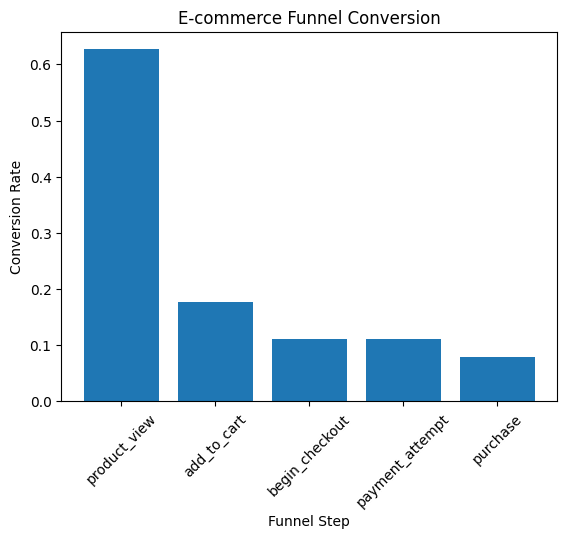

In [40]:
import matplotlib.pyplot as plt

funnel_steps = [
    "product_view",
    "add_to_cart",
    "begin_checkout",
    "payment_attempt",
    "purchase"
]

funnel_rates = fact_sessions[funnel_steps].mean()

plt.figure()
plt.bar(funnel_rates.index, funnel_rates.values)
plt.title("E-commerce Funnel Conversion")
plt.ylabel("Conversion Rate")
plt.xlabel("Funnel Step")
plt.xticks(rotation=45)
plt.show()

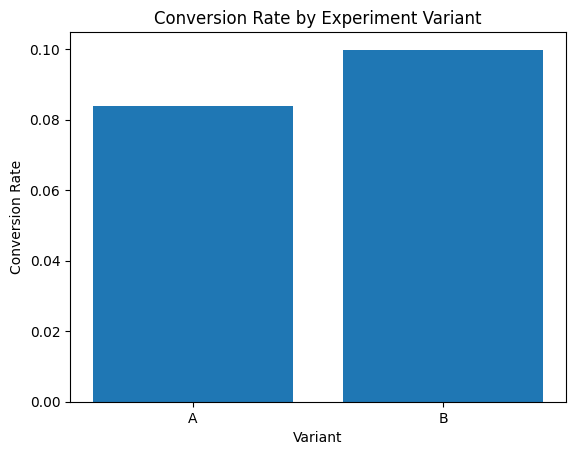

In [41]:
variant_conversion = fact_sessions.groupby("variant")["purchase"].mean()

plt.figure()
plt.bar(variant_conversion.index, variant_conversion.values)
plt.title("Conversion Rate by Experiment Variant")
plt.ylabel("Conversion Rate")
plt.xlabel("Variant")
plt.show()

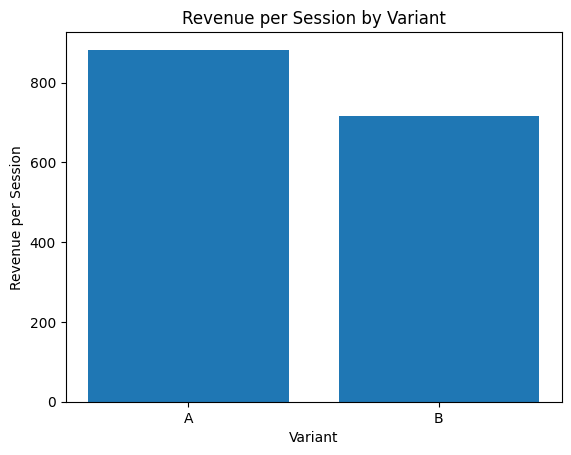

In [42]:
variant_revenue = fact_sessions.groupby("variant")["net_amount"].mean()

plt.figure()
plt.bar(variant_revenue.index, variant_revenue.values)
plt.title("Revenue per Session by Variant")
plt.ylabel("Revenue per Session")
plt.xlabel("Variant")
plt.show()

In [43]:
purchase_times = fact_sessions[fact_sessions["purchase"] == 1]["time_to_purchase_sec"]

purchase_times.describe()

count    708.000000
mean     124.968927
std       47.795405
min       19.000000
25%       87.750000
50%      126.000000
75%      161.000000
max      234.000000
Name: time_to_purchase_sec, dtype: float64

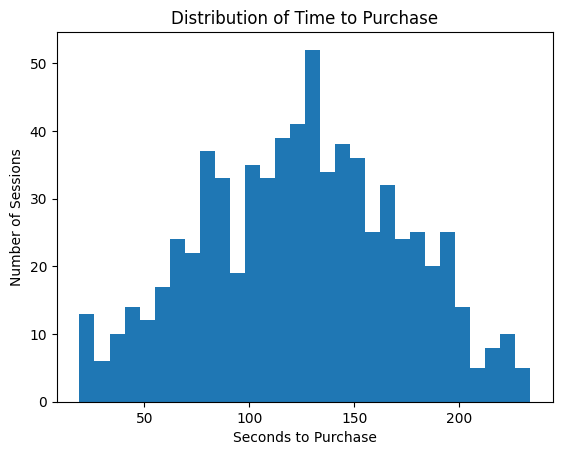

In [44]:
plt.figure()
plt.hist(purchase_times.dropna(), bins=30)
plt.title("Distribution of Time to Purchase")
plt.xlabel("Seconds to Purchase")
plt.ylabel("Number of Sessions")
plt.show()

In [45]:
fact_sessions[fact_sessions["purchase"]==1].groupby("variant")["time_to_purchase_sec"].mean()

variant
A    117.414062
B    122.790541
Name: time_to_purchase_sec, dtype: float64

In [46]:
fact_sessions["session_duration_sec"].describe()

count    9036.000000
mean       69.254537
std        93.871061
min         0.000000
25%         0.000000
50%        38.000000
75%        98.000000
max       518.000000
Name: session_duration_sec, dtype: float64